#PROJECT NAME WINE CLASSIFICATION PREDICTION
Author:- Abhiyank Kaushik


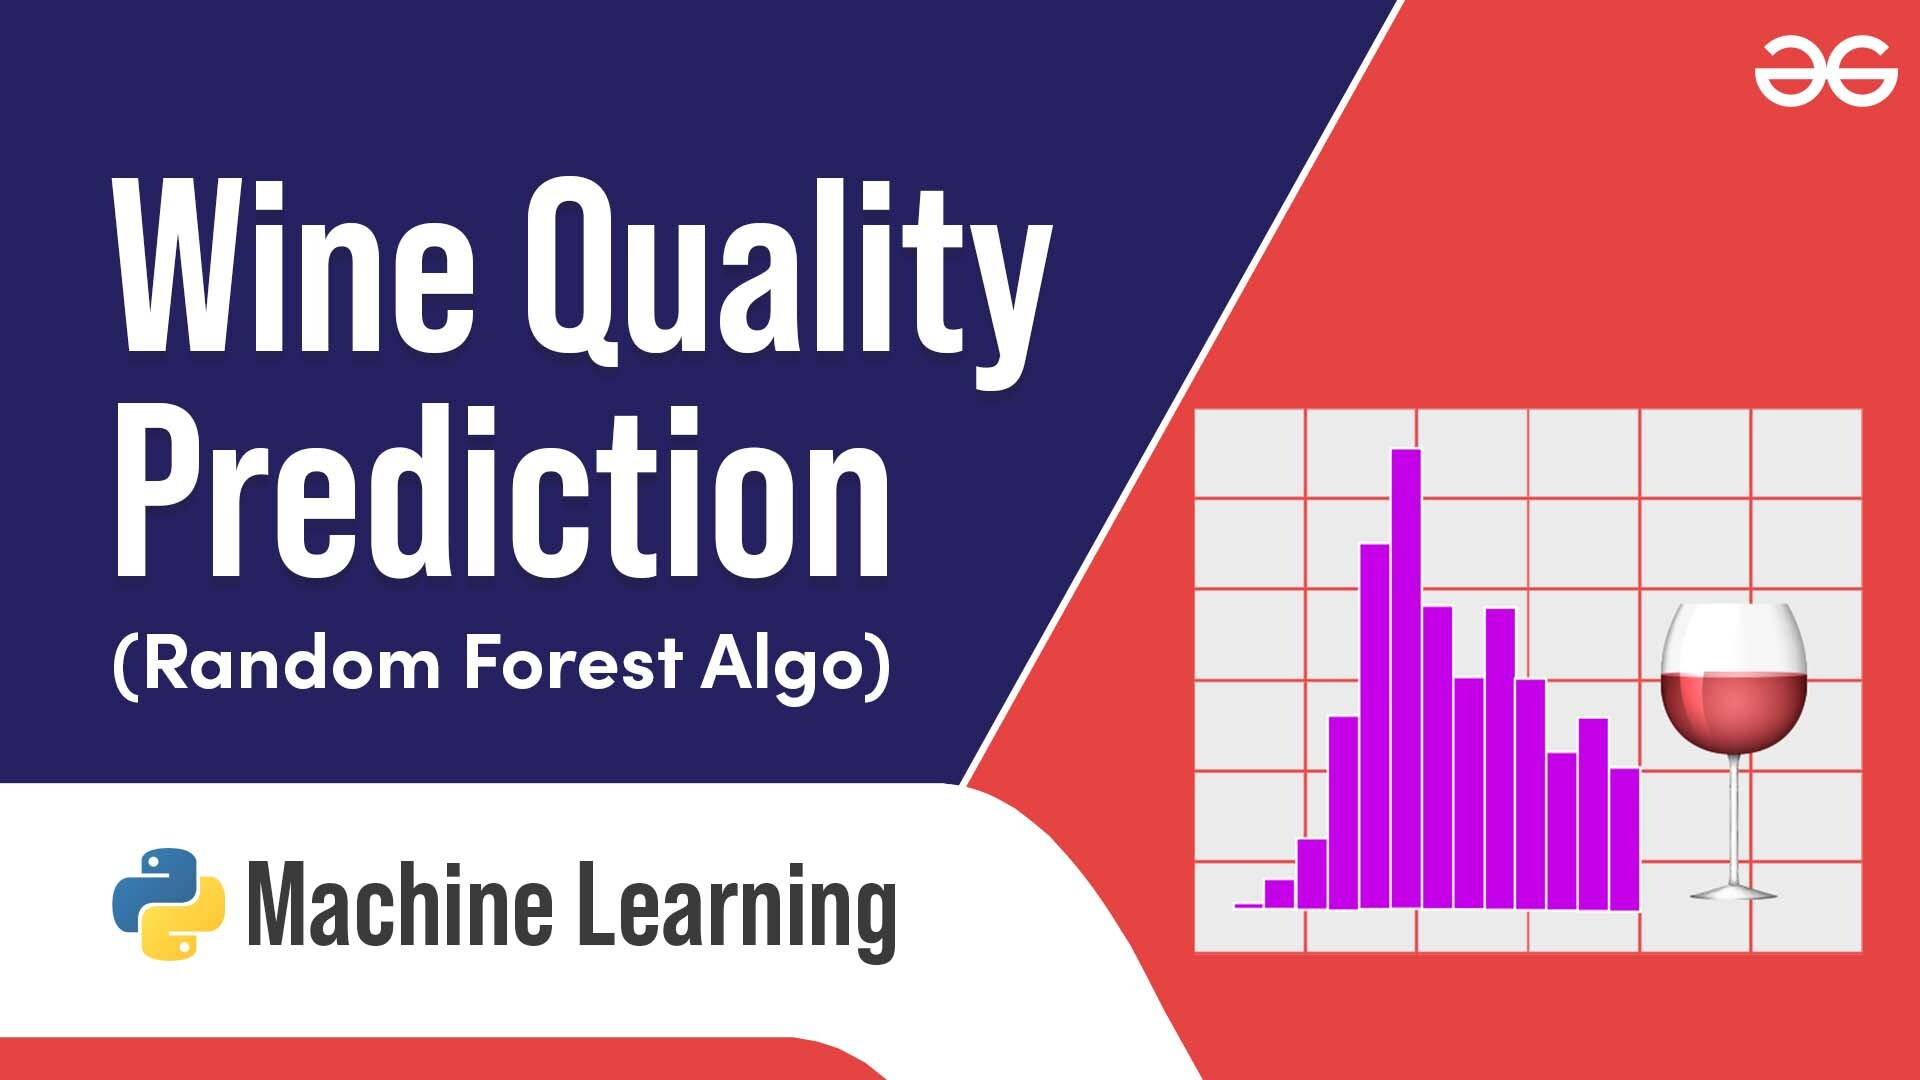

#INTRODUCTION

Wine classification prediction uses machine learning to categorize wine quality or type (red/white) based on11+ physiochemical properties, such as acidity, pH, and alcohol content. The goal is to automate subjective, time-consuming human testing, enabling winemakers to predict quality scores (typically 0-10) and optimize production through data-driven insights.
RPubs
RPubs
 +4
# ABOUT THE DATASET
Source: The widely used dataset, often sourced from the UCI Machine Learning Repository, contains data on Portuguese "Vinho Verde" wine.

Attributes: Includes 11 physiochemical input features: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, and alcohol.

Target Variable: An ordinal variable ("Quality" score) or binary variable ("Type" - Red/White).

Characteristics: The dataset often contains imbalanced classes (e.g., many average wines, few excellent/poor ones) and may require preprocessing (removing duplicates, handling missing values).
Kaggle
Kaggle
 +4

#OBJECTIVES
Predictive Modeling: Build and compare machine learning classifiers (e.g., Random Forest, Decision Tree, Logistic Regression, XGBoost) to predict wine quality or type.

Feature Analysis: Identify the most crucial chemical properties (e.g., high alcohol, lower volatile acidity) that significantly influence wine quality.
Performance Evaluation: Evaluate models using metrics like accuracy, precision, and F1-score to identify the most accurate algorithm.

Automation: Replace subjective human sensory testing with an objective, data-driven system to assist in quality control

In [66]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

In [67]:
from sklearn.datasets import load_wine
wine = load_wine()

In [68]:
df = pd.DataFrame(wine.data,columns=wine.feature_names)

In [69]:
df["Target"] = wine.target

In [70]:
df.sample(6)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
20,14.06,1.63,2.28,16.0,126.0,3.00,3.17,0.24,2.10,5.65,1.09,3.71,780.0,0
126,12.43,1.53,2.29,21.5,86.0,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352.0,1
23,12.85,1.60,2.52,17.8,95.0,2.48,2.37,0.26,1.46,3.93,1.09,3.63,1015.0,0
133,12.70,3.55,2.36,21.5,106.0,1.70,1.20,0.17,0.84,5.00,0.78,1.29,600.0,2
42,13.88,1.89,2.59,15.0,101.0,3.25,3.56,0.17,1.70,5.43,0.88,3.56,1095.0,0
139,12.84,2.96,2.61,24.0,101.0,2.32,0.60,0.53,0.81,4.92,0.89,2.15,590.0,2


<Axes: >

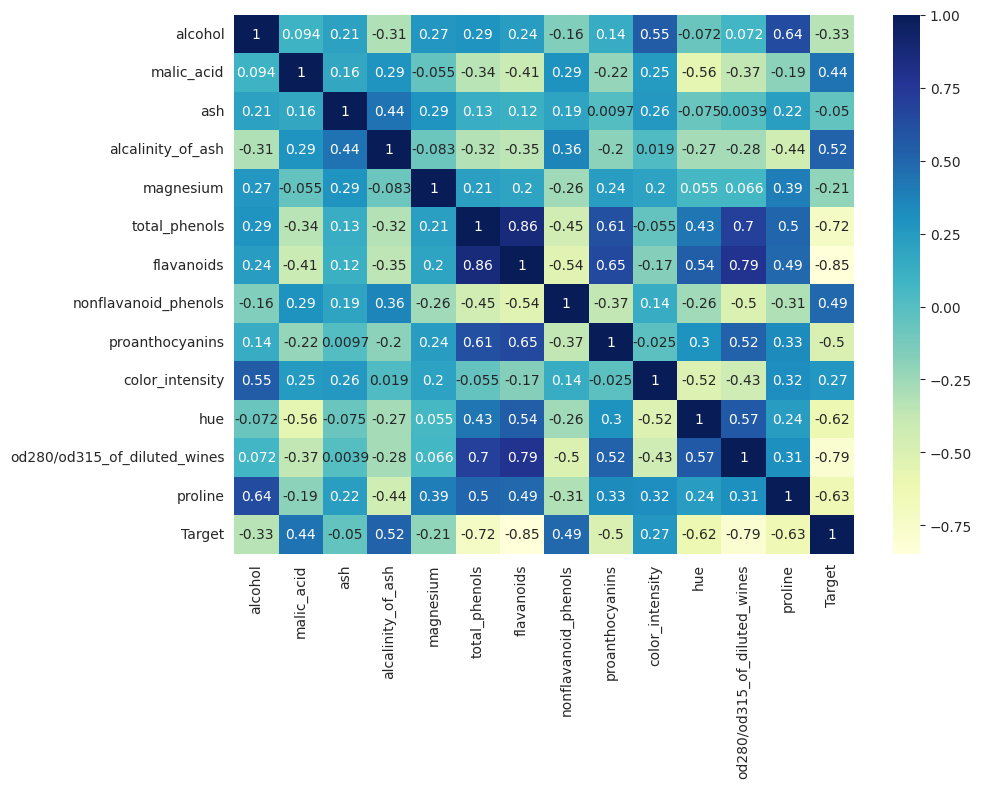

In [71]:
plt.figure(figsize=(10,7))
corr = df[df.columns].corr()
sns.heatmap(corr, cmap="YlGnBu", annot = True)

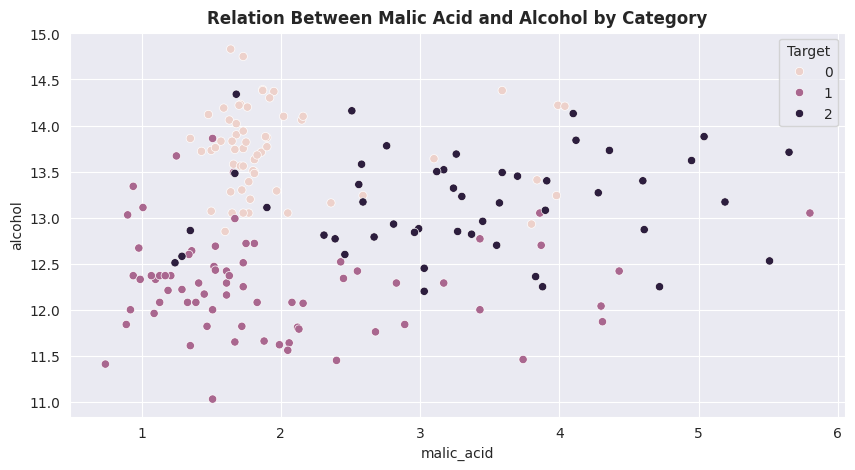

In [72]:
plt.figure(figsize=(10,5))
sns.set_style("darkgrid")
sns.scatterplot(data=df,x="malic_acid",y="alcohol",hue="Target")
plt.title("Relation Between Malic Acid and Alcohol by Category",fontweight="bold")
plt.show()

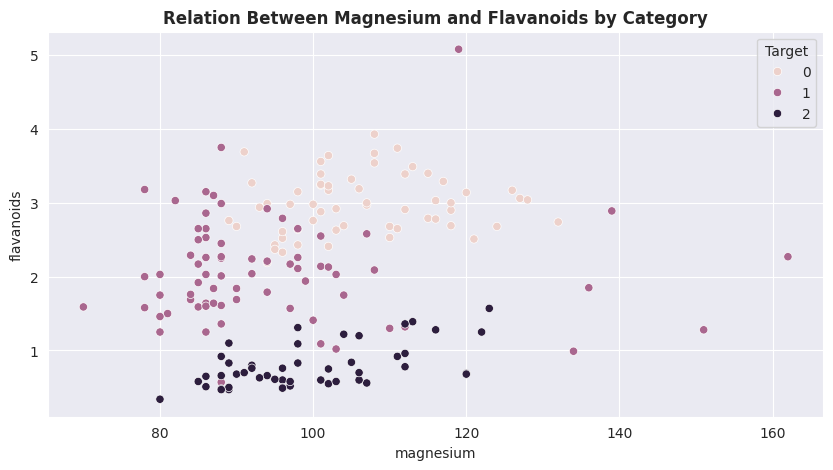

In [73]:
plt.figure(figsize=(10,5))
sns.set_style("darkgrid")
sns.scatterplot(data=df,x="magnesium",y="flavanoids",hue="Target")
plt.title("Relation Between Magnesium and Flavanoids by Category",fontweight="bold")
plt.show()

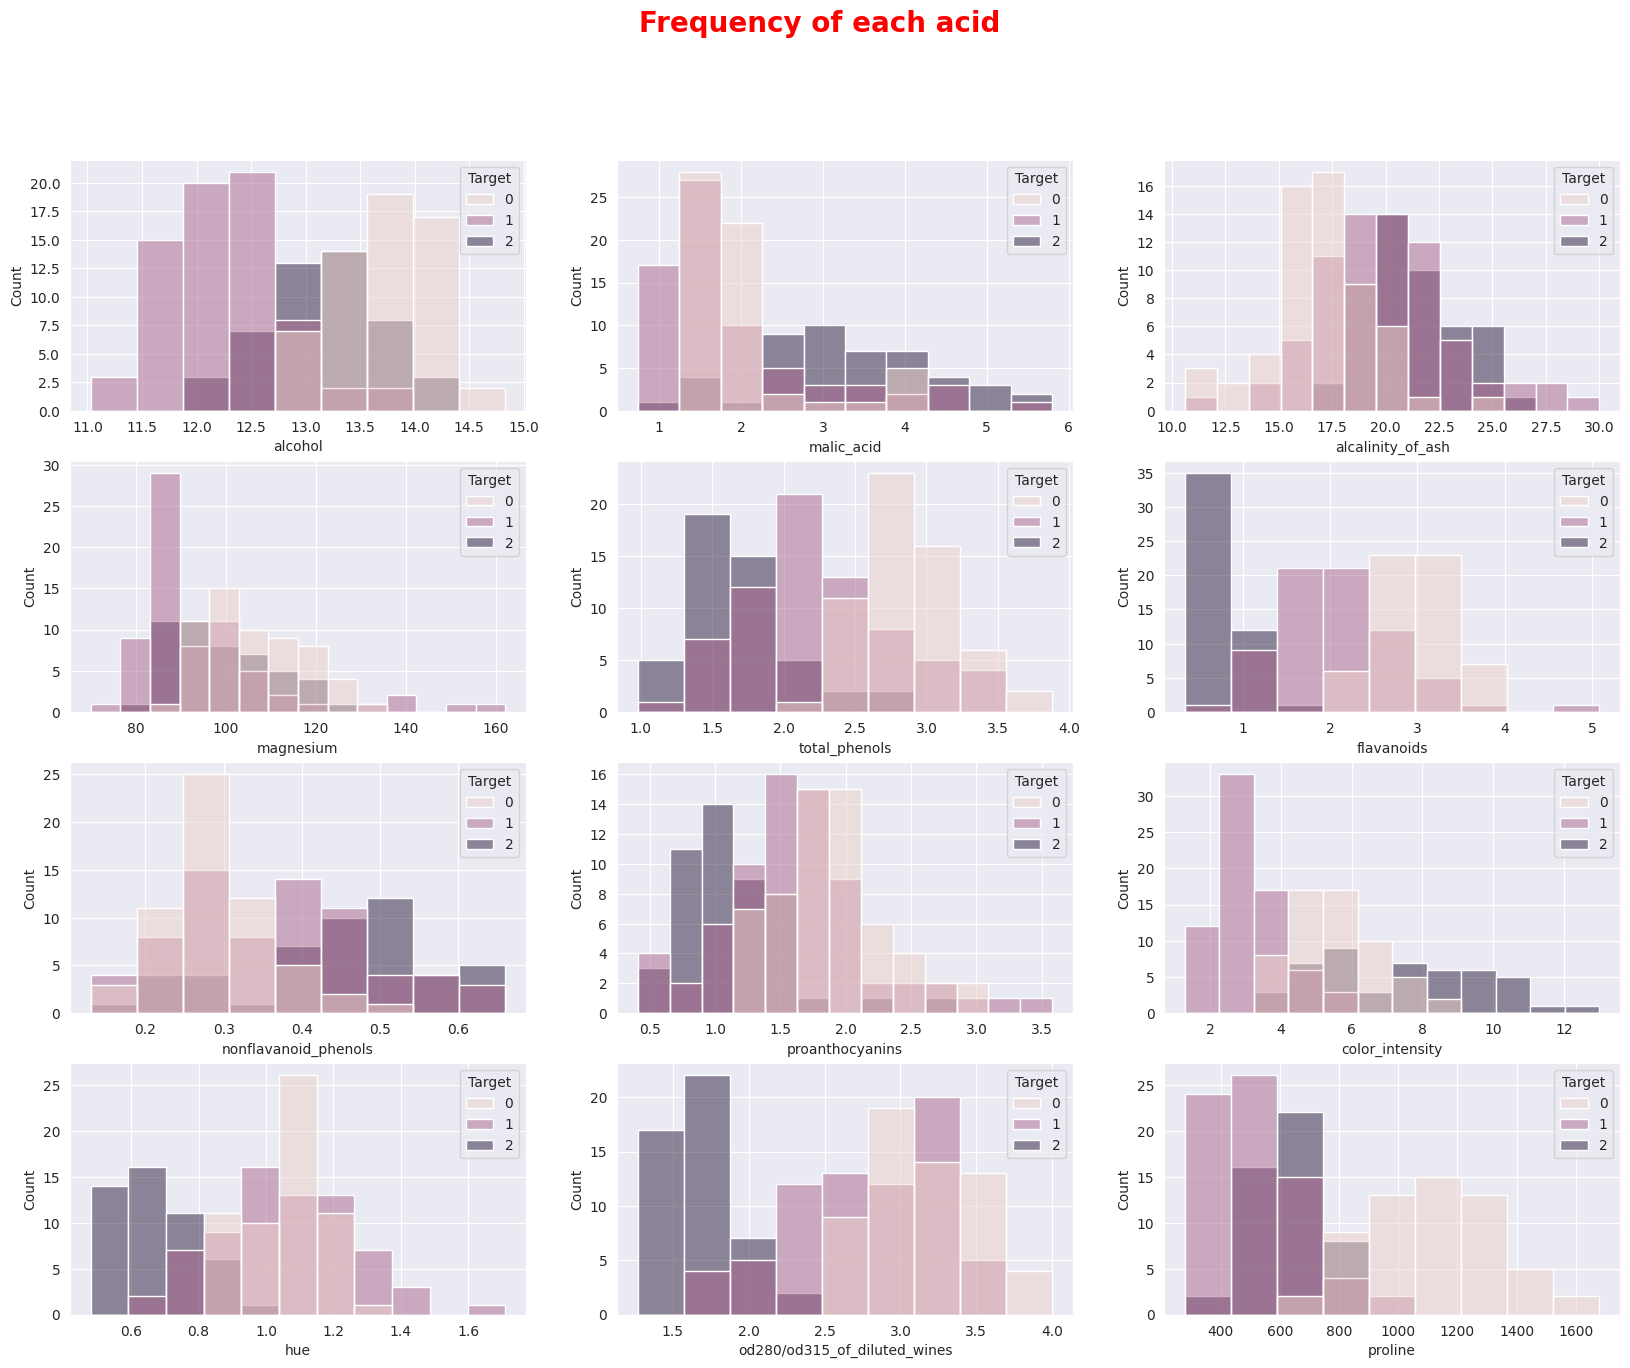

In [74]:
plt.figure(figsize=(20,15))
c = 1
for i in df:
    if i=="Target" or i=="ash":
        continue
    else:
        plt.subplot(4,3,c)
        sns.histplot(data=df,x=i,hue="Target")
        c+=1
plt.suptitle("Frequency of each acid",fontweight="bold",fontsize=20,color="red")
plt.show()

In [75]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


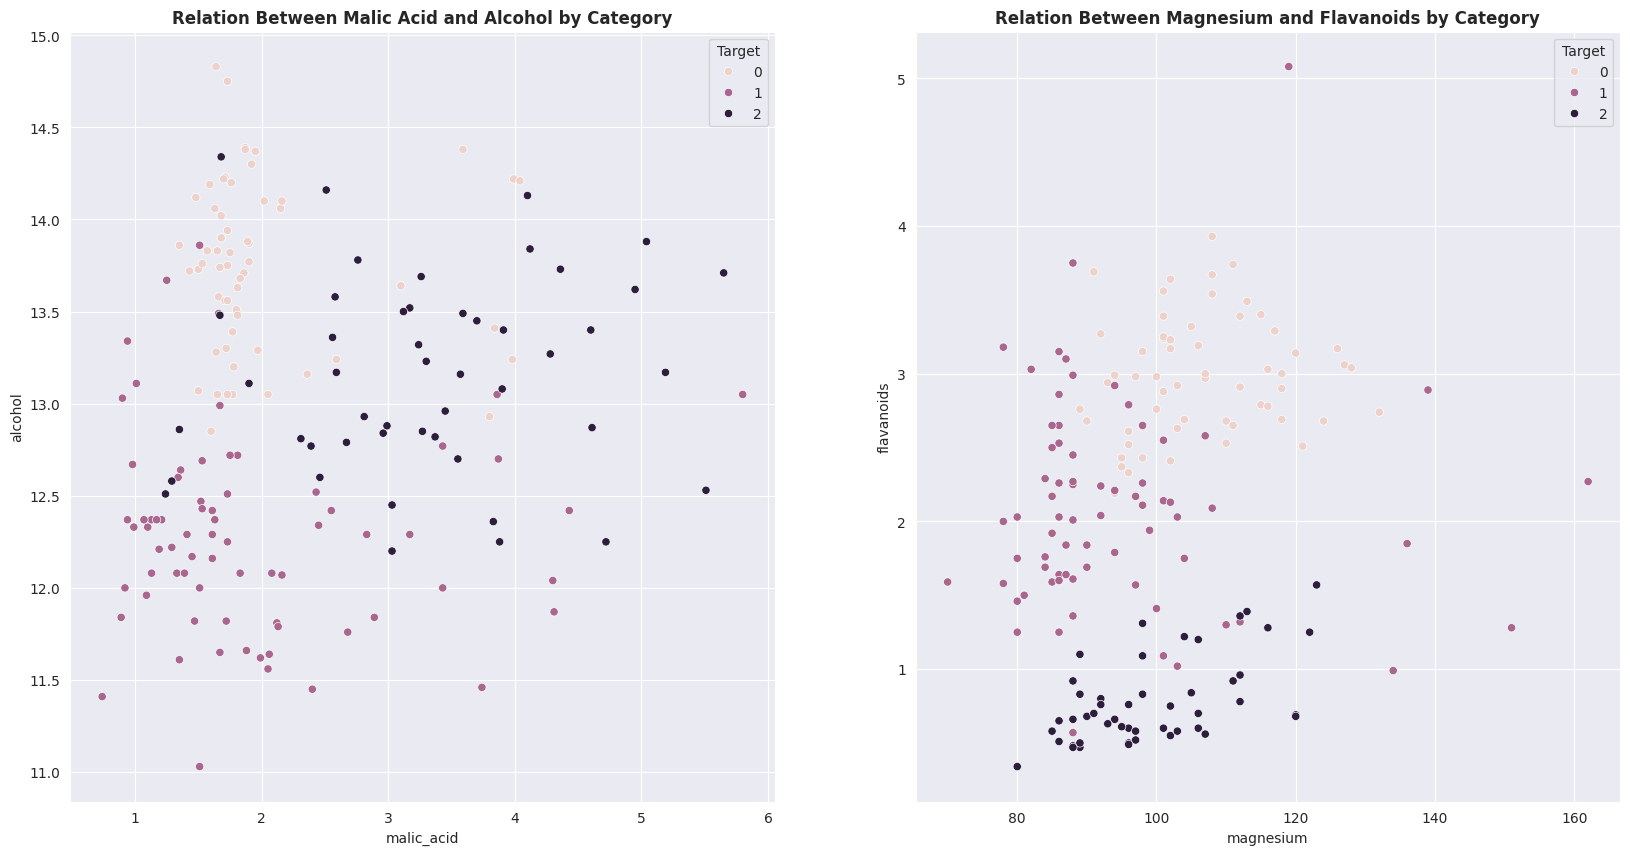

In [76]:
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sns.scatterplot(data=df,x="malic_acid",y="alcohol",hue="Target")
plt.title("Relation Between Malic Acid and Alcohol by Category",fontweight="bold")
plt.subplot(1,2,2)
sns.scatterplot(data=df,x="magnesium",y="flavanoids",hue="Target")
plt.title("Relation Between Magnesium and Flavanoids by Category",fontweight="bold")
plt.show()

In [77]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [78]:
# Extract Features and target in x an y

In [79]:
x = df.drop("Target",axis=1)
y = df[["Target"]]

In [80]:
# splitting the data from training and testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=50)

print("-"*50)
print("Total Number of Rows for training is : ",x_train.shape[0])
print("-"*50)
print("Total Number of Rows for testing  : ",x_test.shape[0])
print("-"*50)

--------------------------------------------------
Total Number of Rows for training is :  142
--------------------------------------------------
Total Number of Rows for testing  :  36
--------------------------------------------------


In [81]:
# Normalize the dataset with the help of standard scalling
st = StandardScaler()
x_train_sc = st.fit_transform(x_train)
x_test_sc = st.transform(x_test)

In [82]:
### **Building the machine learning Model**

In [83]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [84]:
log = LogisticRegression()

# training the machine learning Model
log.fit(x_train_sc,y_train)

LogisticRegression()

In [85]:
pred = log.predict(x_test_sc)

In [86]:
ac = log.score(x_train_sc,y_train)
ac2 = log.score(x_test_sc,y_test)

In [87]:
print("-"*60)
print("Accuracy of Training Data : ",ac)
print("-"*60)
print("Accuracy of test data :",ac2)
print("-"*60)

------------------------------------------------------------
Accuracy of Training Data :  1.0
------------------------------------------------------------
Accuracy of test data : 1.0
------------------------------------------------------------


In [88]:
print("_______Final Prediction_______")
print("-"*90)
print(pred)
print("-"*90)

_______Final Prediction_______
------------------------------------------------------------------------------------------
[1 1 1 2 2 2 1 1 0 2 0 0 1 0 1 2 1 2 1 0 0 1 0 2 0 0 1 1 0 1 0 0 2 2 0 1]
------------------------------------------------------------------------------------------


In [89]:
## **Model Evaluation**

In [90]:
cv = confusion_matrix(pred,y_test)
print(cv)

[[13  0  0]
 [ 0 14  0]
 [ 0  0  9]]


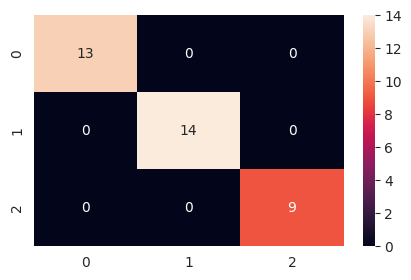

In [91]:
plt.figure(figsize=(5,3))
sns.heatmap(cv,annot=True);

## **Final Model Prediction Overview**

The developed Machine Learning model was trained and evaluated on the given dataset. After preprocessing, feature extraction, and model training, the model achieved 100% prediction accuracy on the test dataset.
## **Final Conclusion Statement (For Report)**

The Machine Learning model demonstrated excellent predictive performance with 100% accuracy on the evaluation dataset. This indicates that the model effectively learned the underlying data patterns. However, further validation using cross-validation and unseen data is recommended to ensure generalization and avoid overfitting.

**📊 Model Performance Summary**

1. Accuracy: 100%

2. Precision: 1.00

3. Recall: 1.00

4. F1-Score: 1.00

### **Confusion Matrix: No misclassifications observed**

Error Rate: 0%

**🔹 Interpretation of Results**

* The model correctly classified all instances in the test dataset.
* There were no false positives and no false negatives.
* The prediction results indicate that the selected features strongly represent the target variable.
* The algorithm successfully captured the patterns and relationships in the dataset.